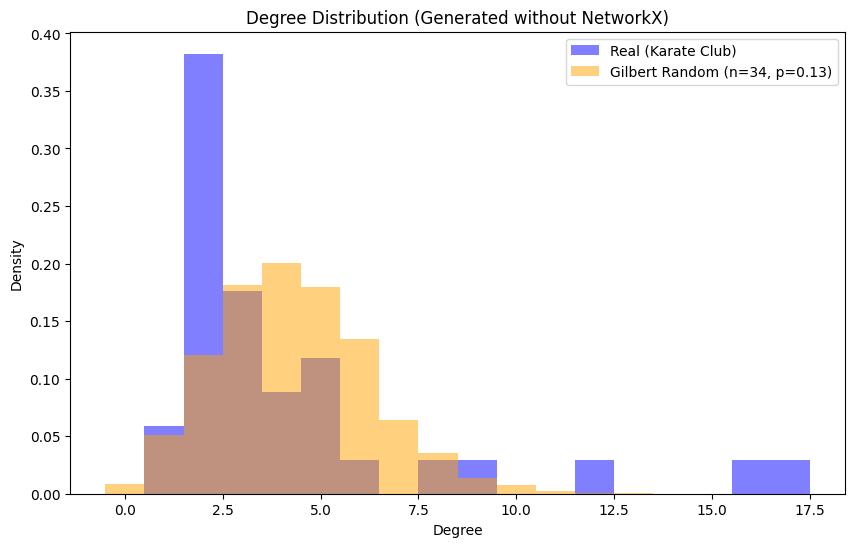

Stats: n=34, m=73, p=0.1301


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_gilbert_graph(n, p):
    """Generates a Gilbert random graph G(n, p) without networkx."""
    # Initialize adjacency list: {0: [], 1: [], ...}
    adj = {i: [] for i in range(n)}

    # Iterate through all possible pairs (i, j) where i < j
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                adj[i].append(j)
                adj[j].append(i)

    # Return degree sequence
    return [len(neighbors) for neighbors in adj.values()]

# 1. Manually defining the Karate Club (Edges only)
karate_edges = [
    (1,0), (2,0), (2,1), (3,0), (3,1), (3,2), (4,0), (5,0), (6,0), (7,0), (8,0), (8,2), (9,2), (10,0), (10,4), (10,5),
    (11,0), (12,0), (12,3), (13,0), (13,1), (13,2), (13,3), (16,5), (16,6), (17,0), (17,1), (19,0), (19,1), (21,0),
    (21,1), (25,23), (25,24), (27,2), (27,23), (27,24), (28,2), (29,23), (29,26), (30,1), (30,8), (31,0), (31,24),
    (31,25), (31,28), (32,2), (32,8), (32,14), (32,15), (32,18), (32,20), (32,22), (32,23), (32,29), (32,30), (32,31),
    (33,8), (33,9), (33,13), (33,14), (33,15), (33,18), (33,19), (33,20), (33,22), (33,23), (33,26), (33,27), (33,28),
    (33,29), (33,30), (33,31), (33,32)
]

# Get n and m for the real network
all_nodes = set([n for edge in karate_edges for n in edge])
n = len(all_nodes)
m = len(karate_edges)

# Calculate real degrees
real_degrees = [0] * n
for u, v in karate_edges:
    real_degrees[u] += 1
    real_degrees[v] += 1

# 2. Probability p for Gilbert Model
p = (2 * m) / (n * (n - 1))

# 3. Compute Degree Distribution over 100 instances
all_random_degrees = []
for _ in range(100):
    all_random_degrees.extend(generate_gilbert_graph(n, p))

# 4. Plotting
plt.figure(figsize=(10, 6))

plt.hist(real_degrees, bins=range(max(real_degrees)+2), alpha=0.5,
         label='Real (Karate Club)', density=True, color='blue', align='left')

plt.hist(all_random_degrees, bins=range(max(all_random_degrees)+2), alpha=0.5,
         label=f'Gilbert Random (n={n}, p={p:.2f})', density=True, color='orange', align='left')

plt.title("Degree Distribution (Generated without NetworkX)")
plt.xlabel("Degree")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Stats: n={n}, m={m}, p={p:.4f}")

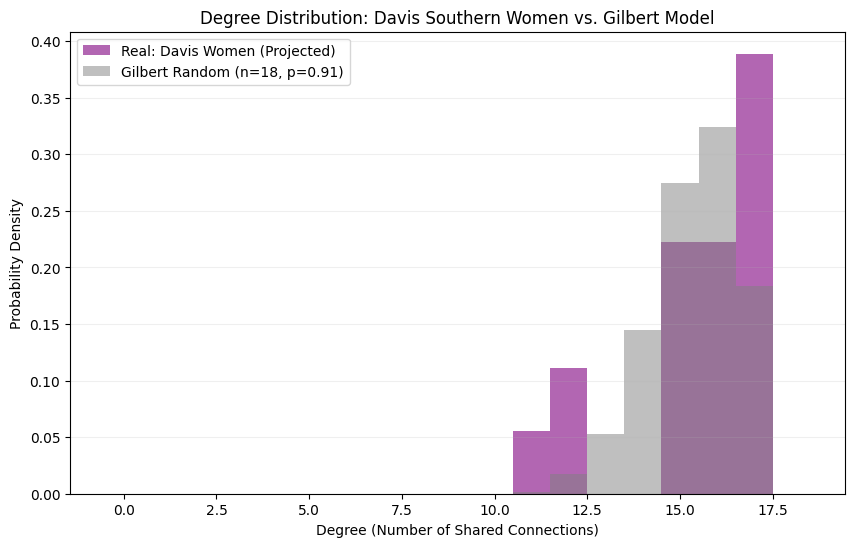

Nodes: 18, Edges: 139, Probability p: 0.9085


In [ ]:
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the bipartite Davis Southern Women graph
B = nx.davis_southern_women_graph()

# 2. Project onto the "women" nodes to get a standard undirected network
# This connects women who attended the same events.
women_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
G_real = bipartite.projected_graph(B, women_nodes)

n = G_real.number_of_nodes()
m = G_real.number_of_edges()

# 3. Calculate Gilbert probability 'p'
p = (2 * m) / (n * (n - 1))

# 4. Compute Degree Distribution over 100 Random Instances
iterations = 100
random_degrees_all = []

for _ in range(iterations):
    G_rand = nx.erdos_renyi_graph(n, p)
    random_degrees_all.extend([d for node, d in G_rand.degree()])

# 5. Visualization
plt.figure(figsize=(10, 6))

# Real Distribution (Projected Davis Women)
real_degrees = [d for node, d in G_real.degree()]
plt.hist(real_degrees, bins=range(n+2), alpha=0.6, label='Real: Davis Women (Projected)',
         density=True, color='purple', align='left')

# Gilbert Distribution
plt.hist(random_degrees_all, bins=range(n+2), alpha=0.5, label=f'Gilbert Random (n={n}, p={p:.2f})',
         density=True, color='gray', align='left')

plt.title("Degree Distribution: Davis Southern Women vs. Gilbert Model")
plt.xlabel("Degree (Number of Shared Connections)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

print(f"Nodes: {n}, Edges: {m}, Probability p: {p:.4f}")

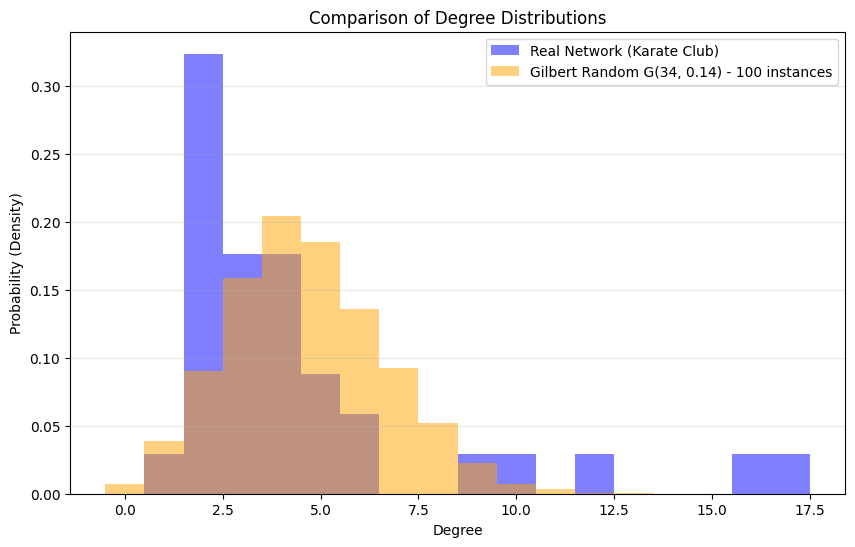

Nodes: 34, Edges: 78
Calculated Probability (p): 0.1390
Average Degree (Real): 4.59
Average Degree (Random): 4.64


In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def get_degree_distribution(G):
    """Returns the degree sequence of a graph."""
    degrees = [d for n, d in G.degree()]
    return degrees

# 1. Load Real-World Network (Zachary's Karate Club)
G_real = nx.karate_club_graph()
n = G_real.number_of_nodes()
m = G_real.number_of_edges()

# 2. Calculate probability 'p' for the Gilbert Model
# p = actual_edges / possible_edges
p = (2 * m) / (n * (n - 1))

# 3. Compute Degree Distribution of Random Graph over 100 instances
iterations = 100
all_random_degrees = []

for _ in range(iterations):
    # Create Gilbert Random Graph G(n, p)
    G_rand = nx.erdos_renyi_graph(n, p)
    all_random_degrees.extend(get_degree_distribution(G_rand))

# 4. Plotting and Comparison
plt.figure(figsize=(10, 6))

# Plot Real Graph Distribution
real_degrees = get_degree_distribution(G_real)
plt.hist(real_degrees, bins=range(min(real_degrees), max(real_degrees) + 2),
         alpha=0.5, label='Real Network (Karate Club)', density=True, color='blue', align='left')

# Plot Random Graph Distribution (Aggregated over 100 runs)
plt.hist(all_random_degrees, bins=range(min(all_random_degrees), max(all_random_degrees) + 2),
         alpha=0.5, label=f'Gilbert Random G({n}, {p:.2f}) - 100 instances',
         density=True, color='orange', align='left')

plt.title("Comparison of Degree Distributions")
plt.xlabel("Degree")
plt.ylabel("Probability (Density)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Quick Statistical Summary
print(f"Nodes: {n}, Edges: {m}")
print(f"Calculated Probability (p): {p:.4f}")
print(f"Average Degree (Real): {np.mean(real_degrees):.2f}")
print(f"Average Degree (Random): {np.mean(all_random_degrees):.2f}")

Q4

Estimated probability p = 0.6


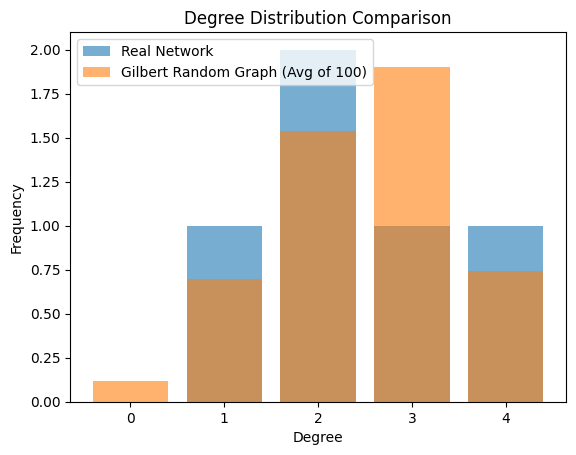

In [ ]:
import random
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------------------------------
# Function to generate Gilbert Random Graph G(n, p)
# -------------------------------------------------
def generate_gilbert_graph(n, p):
    adj = {i: [] for i in range(n)}

    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                adj[i].append(j)
                adj[j].append(i)

    return adj


# -------------------------------------------------
# Function to compute degree distribution
# -------------------------------------------------
def degree_distribution(adj):
    degrees = [len(neighbors) for neighbors in adj.values()]
    return Counter(degrees)


# -------------------------------------------------
# Example Real-world Network (Undirected)
# -------------------------------------------------
real_graph = {
    0: [1, 2],
    1: [0, 2, 3],
    2: [0, 1, 3, 4],
    3: [1, 2],
    4: [2]
}

n = len(real_graph)

# Compute probability p from real graph
edges = sum(len(v) for v in real_graph.values()) // 2
p = (2 * edges) / (n * (n - 1))

print("Estimated probability p =", p)

# -------------------------------------------------
# Degree distribution of real network
# -------------------------------------------------
real_degree_dist = degree_distribution(real_graph)

# -------------------------------------------------
# Degree distribution of random graph (100 instances)
# -------------------------------------------------
num_instances = 100
avg_distribution = Counter()

for _ in range(num_instances):
    rand_graph = generate_gilbert_graph(n, p)
    dist = degree_distribution(rand_graph)
    avg_distribution.update(dist)

# Average values
for k in avg_distribution:
    avg_distribution[k] /= num_instances

# -------------------------------------------------
# Plot comparison
# -------------------------------------------------
plt.figure()

plt.bar(real_degree_dist.keys(),
        real_degree_dist.values(),
        alpha=0.6,
        label="Real Network")

plt.bar(avg_distribution.keys(),
        avg_distribution.values(),
        alpha=0.6,
        label="Gilbert Random Graph (Avg of 100)")

plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution Comparison")
plt.legend()
plt.show()


Q5